# 01 — GRU and LSTM music generation

Two recurrent next-note predictors trained on the Pokémon MIDI corpus.

**Why this version exists.** A straight port of the 2024 notebook to current Keras trained, but it never learned. Training and validation accuracy both stayed at about 1% (loss ≈ 5.1–5.4, perplexity 168–228). The LSTM predicted the same token for every input. Train and validation were equally bad, so this was not overfitting: the models ignored the notes they were given. The causes, and what this notebook changes:

| Problem in the original setup | Change here |
|---|---|
| Each note was fed in as one decimal number, index ÷ 627. Neighbouring numbers are unrelated notes, only 0.0016 apart, and nearly indistinguishable in float16 | **Embedding layer:** every token gets its own learned 128-dim vector |
| RMSprop at 0.005 was unstable (first-epoch loss worse than random guessing), with no gradient clipping | **Adam at 1e-3 with gradient clipping**, and the learning rate halves when validation loss stalls |
| 627 tokens, many of them chords that appear a handful of times | **Rare tokens → `<unk>`**, and the same note spelled two ways (C#4 / D-4) is one token |
| 9–12 M parameters (three stacked layers, two bidirectional) for ~150 k overlapping windows | **Two 512-unit layers**, not bidirectional: ~2–3 M parameters |
| Validation was the last 10% of windows | **Validation by song**, so it measures music the model never saw |
| No augmentation | **Random transposition** of each training window by -5 to +6 semitones |
| Greedy / plain sampling | **Temperature 0.8 + top-k 10**, and `<unk>` is never generated |

Unchanged: 100-note input windows, next-note prediction with cross-entropy, dropout 0.3, the Dense(256) layer, 500-note generated pieces, and the same metrics and figures. The notebook also prints a **context-free baseline**: the validation loss of a model that only knows how common each token is. The reproduction run sat right at that level. A working model has to beat it clearly.

The original 2024 notebook is kept in `notebooks/original_2024/`.

**Running in short Colab sessions.** Nothing is lost if Colab disconnects:

1. On Colab, the notebook mounts your Google Drive and keeps everything in `MyDrive/symphony-of-algorithms/`: the dataset, the parsed notes, checkpoints, logs and results. When the Google popup appears, choose the account you use Colab with and **tick every permission box**. Otherwise Drive fails with "credential propagation was unsuccessful", and the notebook continues without the ability to resume.
2. Training saves its state after every epoch. If the session ends, reconnect and choose *Run all* again. Training continues from the last finished epoch.
3. A model that has already finished is skipped and its saved metrics are loaded. To split the work, set `MODELS_TO_RUN = ["gru"]` for one session and `["lstm"]` for the next.
4. To retrain from scratch, set `FRESH_START = True`.

The models are much smaller than before, so epochs are shorter. Exact times depend on when early stopping triggers.

**Running on Google Colab.** Upload this notebook, then choose *Runtime → Change runtime type → T4 GPU* and *Runtime → Run all*. The paths cell will ask you to upload `data/pokemon_midis.zip` from the repo. The generated music is saved as `.mid`, rendered to `.wav` and played inline. The last cell downloads every output as one zip. Unzip it into the repo's `results/` folder to keep the outputs.

**Running locally.** Run `pip install -r requirements.txt`, then open this notebook from the repo's `notebooks/` folder. WAV rendering needs [FluidSynth](https://www.fluidsynth.org/) and a General MIDI soundfont. Without them the notebook still saves the `.mid` files.

## 1. Setup

In [1]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "music21"], check=True)
    # FluidSynth + a General MIDI soundfont render the generated .mid files to playable .wav audio
    subprocess.run("apt-get update -qq && apt-get install -y -qq fluidsynth fluid-soundfont-gm > /dev/null",
                   shell=True, check=True)

In [2]:
import json
import math
import pickle
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from music21 import converter, instrument, note, chord, stream
from scipy.spatial.distance import euclidean
from sklearn.metrics import mean_squared_error
from IPython.display import Audio, display

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | Keras 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ---- Configuration --------------------------------------------------------
SEQUENCE_LENGTH = 100       # original: 100-note input windows
VAL_FRACTION = 0.1          # share of songs held out for validation
TRANSPOSE_SHIFTS = list(range(-5, 7))   # semitones; training windows only
MIN_COUNT = 10              # tokens seen fewer times (over all transposed training copies) become <unk>
TRAIN_STRIDE, VAL_STRIDE = 1, 5         # a window starts every note (train) / every 5 notes (validation)

EMBED_DIM = 128
UNITS = 512
DROPOUT = 0.3               # original
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
MAX_EPOCHS = 40             # upper limit; early stopping usually ends sooner
EARLY_STOPPING_PATIENCE = 5

MODELS_TO_RUN = ["gru", "lstm"]   # e.g. ["gru"] in one session and ["lstm"] in the next
USE_MIXED_PRECISION = True  # float16 on the GPU; safe now that tokens go through an embedding
SAVE_TO_DRIVE = True        # Colab: keep data, checkpoints and results in Google Drive so training can resume
FRESH_START = False         # True deletes this notebook's checkpoints / logs / metrics and retrains

GEN_NOTES = 500             # original: 500 notes per generated piece
TEMPERATURE = 0.8           # 0 = greedy argmax
TOP_K = 10
N_GEN_SAMPLES = 10          # sequences generated for novelty / diversity / FAD
N_REAL_SAMPLES = 500        # real windows they are compared against

np.random.seed(1)
tf.random.set_seed(2)
rng = np.random.default_rng(1)

if USE_MIXED_PRECISION and tf.config.list_physical_devices("GPU"):
    keras.mixed_precision.set_global_policy("mixed_float16")

COLAB_ROOT = Path("/content/symphony-of-algorithms")
if IN_COLAB and SAVE_TO_DRIVE:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
        COLAB_ROOT = Path("/content/drive/MyDrive/symphony-of-algorithms")
    except Exception as e:
        print(f"Could not connect Google Drive ({e}).\n"
              "Continuing without it - progress will NOT survive a disconnect. To enable resuming, re-run this "
              "cell and tick every permission box in the Google popup.")

# ---- Paths: locally, find the repo from notebooks/ or the repo root; on Colab, upload the dataset
def find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "pokemon_midis.zip").exists():
            return p
    return None


REPO_ROOT = find_repo_root()
if REPO_ROOT is None and IN_COLAB and (COLAB_ROOT / 'data' / 'pokemon_midis.zip').exists():
    REPO_ROOT = COLAB_ROOT   # dataset uploaded in an earlier session
if REPO_ROOT is None:
    if not IN_COLAB:
        raise FileNotFoundError("data/pokemon_midis.zip not found - run this notebook from inside the repo.")
    from google.colab import files
    REPO_ROOT = COLAB_ROOT
    (REPO_ROOT / "data").mkdir(parents=True, exist_ok=True)
    print("Select data/pokemon_midis.zip from the repo:")
    uploaded = files.upload()
    (REPO_ROOT / "data" / "pokemon_midis.zip").write_bytes(next(iter(uploaded.values())))

DATA_ZIP = REPO_ROOT / "data" / "pokemon_midis.zip"
MIDI_DIR = REPO_ROOT / "data" / "Pokemon MIDIs"
if not MIDI_DIR.exists():
    with zipfile.ZipFile(DATA_ZIP) as zf:
        zf.extractall(DATA_ZIP.parent)

AUDIO_DIR = REPO_ROOT / "results" / "audio"
WEIGHTS_DIR = REPO_ROOT / "Weights"
for d in (AUDIO_DIR, WEIGHTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"{len(list(MIDI_DIR.glob('*.mid')))} MIDI files in {MIDI_DIR.relative_to(REPO_ROOT)}")

Mounted at /content/drive
Select data/pokemon_midis.zip from the repo:


Saving pokemon_midis.zip to pokemon_midis.zip
307 MIDI files in data/Pokemon MIDIs


In [4]:
SOUNDFONT = Path("/usr/share/sounds/sf2/FluidR3_GM.sf2")


def midi_to_wav(midi_path):
    # Render a .mid file to .wav with FluidSynth (installed automatically on Colab)
    if shutil.which("fluidsynth") is None or not SOUNDFONT.exists():
        print("FluidSynth or the soundfont is not installed - skipping WAV rendering (the .mid file is saved).")
        return None
    wav_path = midi_path.with_suffix(".wav")
    subprocess.run(["fluidsynth", "-ni", "-F", str(wav_path), "-r", "44100", str(SOUNDFONT), str(midi_path)],
                   check=True, capture_output=True)
    return wav_path


def save_and_play(midi_path):
    wav_path = midi_to_wav(midi_path)
    print(f"Saved {midi_path.relative_to(REPO_ROOT)}" + (f" and {wav_path.relative_to(REPO_ROOT)}" if wav_path else ""))
    if wav_path:
        display(Audio(str(wav_path)))

# Same definitions as the GAN evaluation in the original project (results/figures/gan/*.png)
def novelty_metric(generated_sequences, real_sequences):
    distances = []
    for gen_seq in generated_sequences:
        gen_seq_flat = gen_seq.flatten()
        real_distances = [euclidean(gen_seq_flat, real_seq.flatten()) for real_seq in real_sequences]
        distances.append(np.mean(real_distances))
    return np.mean(distances)


def nearest_neighbour_novelty(generated_sequences, real_sequences):
    # The definition RESULTS.md describes: distance to the *closest* real sequence
    return np.mean([min(euclidean(g.flatten(), r.flatten()) for r in real_sequences)
                    for g in generated_sequences])


def diversity_metric(sequences):
    n = len(sequences)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(euclidean(sequences[i].flatten(), sequences[j].flatten()))
    return np.mean(distances)


def fad_metric(generated_sequences, real_sequences):
    gen_means = np.mean(generated_sequences, axis=0)
    gen_vars = np.var(generated_sequences, axis=0)
    real_means = np.mean(real_sequences, axis=0)
    real_vars = np.var(real_sequences, axis=0)
    mean_diff = mean_squared_error(gen_means.flatten(), real_means.flatten())
    var_diff = mean_squared_error(gen_vars.flatten(), real_vars.flatten())
    return mean_diff + var_diff


def generation_metrics(generated_sequences, real_sequences):
    return {
        "novelty (mean distance, as in original code)": float(novelty_metric(generated_sequences, real_sequences)),
        "novelty (nearest neighbour, as in RESULTS.md)": float(nearest_neighbour_novelty(generated_sequences, real_sequences)),
        "diversity": float(diversity_metric(generated_sequences)),
        "FAD proxy": float(fad_metric(generated_sequences, real_sequences)),
    }

def create_midi(prediction_output, midi_path):
    # Convert note / chord tokens back to a MIDI file (original logic; every note is now played on piano)
    offset = 0
    output_notes = []
    for pattern in prediction_output:
        if ("." in pattern) or pattern.isdigit():      # pattern is a chord
            chord_notes = []
            for current_note in pattern.split("."):
                new_note = note.Note(int(current_note))
                new_note.storedInstrument = instrument.Piano()
                chord_notes.append(new_note)
            new_chord = chord.Chord(chord_notes)
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:                                          # pattern is a note
            new_note = note.Note(pattern)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)
        offset += 0.5                                  # so that notes do not stack
    midi_stream = stream.Stream(output_notes)
    midi_stream.insert(0, instrument.Piano())
    midi_stream.write("midi", fp=str(midi_path))

def save_summary(model, path):
    lines = []
    model.summary(print_fn=lambda line, *args, **kwargs: lines.append(line))
    path.write_text("\n".join(lines), encoding="utf-8")
    model.summary()

## 2. Read the data

Each song becomes a list of tokens, parsed with music21 as in the original: the first instrument part, with notes and chords. Notes are stored by pitch, so C#4 and D-4 are one token (named with sharps). A chord is its set of pitch classes, for example `0.4.7` for a C major triad. Parsing is cached on Drive after the first run.

In [5]:
NOTES_CACHE = REPO_ROOT / "data" / "notes_by_song.pkl"
NOTE_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]   # sharps only: "-" means flat in music21
MIN_MIDI, MAX_MIDI = 12, 127   # octave 0 and up, so every name is unambiguous


def midi_to_name(midi_number):
    return f"{NOTE_NAMES[midi_number % 12]}{midi_number // 12 - 1}"


NAME_TO_MIDI = {midi_to_name(m): m for m in range(MIN_MIDI, MAX_MIDI + 1)}


def song_tokens(midi):
    try:  # file has instrument parts: use the first part (original)
        notes_to_parse = instrument.partitionByInstrument(midi).parts[0].recurse()
    except Exception:  # file has notes in a flat structure
        notes_to_parse = midi.flatten().notes
    tokens = []
    for element in notes_to_parse:
        if isinstance(element, note.Note):
            if MIN_MIDI <= element.pitch.midi <= MAX_MIDI:
                tokens.append(midi_to_name(element.pitch.midi))
        elif isinstance(element, chord.Chord):
            tokens.append(".".join(str(pc) for pc in sorted({p.pitchClass for p in element.pitches})))
    return tokens


if NOTES_CACHE.exists():
    songs = pickle.loads(NOTES_CACHE.read_bytes())
else:
    midi_files = sorted(MIDI_DIR.glob("*.mid"))
    print(f"Parsing {len(midi_files)} MIDI files with music21 (a few minutes; cached afterwards)...")
    songs = []
    for file in midi_files:
        try:
            tokens = song_tokens(converter.parse(file))
        except Exception as e:  # a few fan transcriptions are malformed
            print(f"  skipped {file.name}: {e!r}")
            continue
        if tokens:
            songs.append(tokens)
    NOTES_CACHE.write_bytes(pickle.dumps(songs))

songs = [s for s in songs if len(s) > SEQUENCE_LENGTH]
print(f"{len(songs)} songs longer than {SEQUENCE_LENGTH} tokens, {sum(map(len, songs)):,} tokens in total")

Parsing 307 MIDI files with music21 (a few minutes; cached afterwards)...


/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=6, data=b'Pok\xe9mon: Elite Four (Piano)'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pok\xe9mon Gym'>; getting generic Instrument
  warnings.warn(


264 songs longer than 100 tokens, 128,106 tokens in total


## 3. Split by song, build the vocabulary, and window

Songs are split before windowing, so no song appears in both sets. The vocabulary is built from the training songs in every transposition. A token that appears fewer than `MIN_COUNT` times becomes `<unk>`. `TRANSPOSE[token, shift]` gives each token's transposed version, so a whole training window can be moved to a new key with one lookup.

In [6]:
order = rng.permutation(len(songs))
n_val = max(1, int(VAL_FRACTION * len(songs)))
val_songs = [songs[i] for i in order[:n_val]]
train_songs = [songs[i] for i in order[n_val:]]


def transpose_token(token, shift):
    if token in NAME_TO_MIDI:                                   # a single note
        m = NAME_TO_MIDI[token] + shift
        return midi_to_name(m) if MIN_MIDI <= m <= MAX_MIDI else None
    return ".".join(str(pc) for pc in sorted({(int(pc) + shift) % 12 for pc in token.split(".")}))  # a chord


augmented_counts = Counter()
for song in train_songs:
    for shift in TRANSPOSE_SHIFTS:
        augmented_counts.update(t for t in (transpose_token(tok, shift) for tok in song) if t is not None)

UNK, UNK_ID = "<unk>", 0
vocab = [UNK] + sorted(t for t, c in augmented_counts.items() if c >= MIN_COUNT)
token_to_id = {t: i for i, t in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

TRANSPOSE = np.zeros((VOCAB_SIZE, len(TRANSPOSE_SHIFTS)), dtype=np.int32)
for token, i in token_to_id.items():
    for j, shift in enumerate(TRANSPOSE_SHIFTS):
        TRANSPOSE[i, j] = token_to_id.get(transpose_token(token, shift), UNK_ID) if token != UNK else UNK_ID


def encode(song):
    return np.array([token_to_id.get(t, UNK_ID) for t in song], dtype=np.int32)


train_ids = [encode(s) for s in train_songs]
val_ids = [encode(s) for s in val_songs]
val_unk = np.mean(np.concatenate(val_ids) == UNK_ID)
print(f"train {len(train_songs)} songs, validation {len(val_songs)} songs")
print(f"vocabulary {VOCAB_SIZE} tokens (reproduction run: 627) | validation tokens that are <unk>: {val_unk:.1%}")

train 238 songs, validation 26 songs
vocabulary 714 tokens (reproduction run: 627) | validation tokens that are <unk>: 0.2%


In [7]:
BaseDataset = getattr(keras.utils, "PyDataset", keras.utils.Sequence)   # Keras 3 / Keras 2


class WindowDataset(BaseDataset):
    # Batches of (100 tokens -> next token); training windows are moved to a random key each time
    def __init__(self, songs_ids, stride, augment, shuffle):
        super().__init__()
        self.songs = songs_ids
        self.index = np.array([(i, start) for i, song in enumerate(songs_ids)
                               for start in range(0, len(song) - SEQUENCE_LENGTH, stride)])
        self.augment, self.shuffle = augment, shuffle
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.index) / BATCH_SIZE)

    def __getitem__(self, batch):
        rows = self.index[self.order[batch * BATCH_SIZE:(batch + 1) * BATCH_SIZE]]
        x = np.empty((len(rows), SEQUENCE_LENGTH), dtype=np.int32)
        y = np.empty(len(rows), dtype=np.int32)
        for k, (i, start) in enumerate(rows):
            window = self.songs[i][start:start + SEQUENCE_LENGTH + 1]
            if self.augment:
                window = TRANSPOSE[window, rng.integers(len(TRANSPOSE_SHIFTS))]
            x[k], y[k] = window[:-1], window[-1]
        return x, y

    def on_epoch_end(self):
        self.order = rng.permutation(len(self.index)) if self.shuffle else np.arange(len(self.index))


train_ds = WindowDataset(train_ids, TRAIN_STRIDE, augment=True, shuffle=True)
val_ds = WindowDataset(val_ids, VAL_STRIDE, augment=False, shuffle=False)
print(f"{len(train_ds.index):,} training windows ({len(train_ds):,} batches), "
      f"{len(val_ds.index):,} validation windows")

# Context-free baseline: always predict each token's training frequency
train_counts = np.bincount(np.concatenate(train_ids), minlength=VOCAB_SIZE) + 1
val_targets = np.array([val_ids[i][start + SEQUENCE_LENGTH] for i, start in val_ds.index])
BASELINE_LOSS = float(-np.mean(np.log(train_counts[val_targets] / train_counts.sum())))
print(f"Context-free baseline: validation loss {BASELINE_LOSS:.3f} (perplexity {math.exp(BASELINE_LOSS):.1f}). "
      "The models must get clearly below this.")

94,140 training windows (1,471 batches), 1,522 validation windows
Context-free baseline: validation loss 5.103 (perplexity 164.5). The models must get clearly below this.


## 4. Model, training and evaluation

In [8]:
def build_model(cell):
    model = keras.Sequential([
        keras.Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),
        layers.Embedding(VOCAB_SIZE, EMBED_DIM),
        cell(UNITS, return_sequences=True),
        layers.Dropout(DROPOUT),
        cell(UNITS),
        layers.Dropout(DROPOUT),
        layers.Dense(256),
        layers.Dropout(DROPOUT),
        layers.Dense(VOCAB_SIZE),
        layers.Activation("softmax", dtype="float32"),   # float32 output under mixed precision
    ], name=cell.__name__.lower())
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
                  metrics=["accuracy"])
    return model


def plot_history(history, tag, fig_dir):
    plt.figure(figsize=(12, 4))
    for i, (key, label) in enumerate([("accuracy", "Accuracy"), ("loss", "Loss")], start=1):
        plt.subplot(1, 2, i)
        plt.plot(history[key], label=f"Training {label.lower()}", color="darkred")
        plt.plot(history[f"val_{key}"], label=f"Validation {label.lower()}", color="steelblue")
        if key == "loss":
            plt.axhline(BASELINE_LOSS, color="grey", linestyle="--", linewidth=1, label="Context-free baseline")
        plt.xlabel("Num of Epochs")
        plt.ylabel(label)
        plt.title(f"{tag.split('_')[0].upper()} {label.lower()}")
        plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / "accuracy_and_loss_graph.png", dpi=150)
    plt.show()


def sample_index(probs):
    probs = np.asarray(probs, dtype=np.float64).copy()
    probs[UNK_ID] = 0.0                                  # never generate <unk>
    if TOP_K:
        probs[probs < np.sort(probs)[-TOP_K]] = 0.0
    if TEMPERATURE == 0:
        return int(np.argmax(probs))
    p = np.power(probs, 1.0 / TEMPERATURE)               # same as dividing the logits by the temperature
    return int(rng.choice(len(p), p=p / p.sum()))


def generate_ids(model, n_notes):
    # Seed with a random window from a validation song, then predict one token at a time and feed it back
    song = val_ids[rng.integers(len(val_ids))]
    start = rng.integers(len(song) - SEQUENCE_LENGTH)
    pattern = list(song[start:start + SEQUENCE_LENGTH])
    generated = []
    for _ in range(n_notes):
        x = np.array(pattern[-SEQUENCE_LENGTH:], dtype=np.int32)[None, :]
        index = sample_index(np.asarray(model(x, training=False))[0])
        generated.append(index)
        pattern.append(index)
    return generated

In [9]:
def load_csv_history(csv_path):
    # Full per-epoch history, including epochs trained in earlier (disconnected) sessions
    if not csv_path.exists():
        return {}
    df = pd.read_csv(csv_path).drop_duplicates("epoch", keep="last").sort_values("epoch")
    return {c: df[c].tolist() for c in df.columns if c != "epoch"}


def run_model(name, cell):
    tag = f"{name}_improved"
    fig_dir = REPO_ROOT / "results" / "figures" / tag
    fig_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = WEIGHTS_DIR / f"best_{tag}.keras"
    backup_dir = WEIGHTS_DIR / f"{tag}_backup"
    done_marker = WEIGHTS_DIR / f"{tag}_training_done"
    csv_path = fig_dir / "epochs_with_accuracy.csv"
    metrics_path = REPO_ROOT / "results" / f"{tag}_metrics.json"

    if FRESH_START:
        for p in (checkpoint_path, done_marker, csv_path, metrics_path):
            p.unlink(missing_ok=True)
        shutil.rmtree(backup_dir, ignore_errors=True)
    if metrics_path.exists():
        print(f"{name.upper()} finished in an earlier session - loading its saved metrics (FRESH_START = True retrains).")
        return json.loads(metrics_path.read_text())["metrics"]

    if not done_marker.exists():
        keras.backend.clear_session()
        model = build_model(cell)
        save_summary(model, fig_dir / "model_summary.txt")
        previous = load_csv_history(csv_path)
        if previous:
            print(f"Resuming {name.upper()} after {len(previous['loss'])} completed epochs")
        model.fit(
            train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, verbose=1,
            callbacks=[
                keras.callbacks.BackupAndRestore(str(backup_dir)),      # resume here after a disconnect
                keras.callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True,
                                                mode="min",
                                                initial_value_threshold=min(previous["val_loss"]) if previous else None),
                keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOPPING_PATIENCE),
                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
                keras.callbacks.CSVLogger(str(csv_path), append=True),
            ],
        )
        done_marker.touch()

    history = load_csv_history(csv_path)
    plot_history(history, tag, fig_dir)

    # Everything below uses the checkpoint with the best validation loss
    model = keras.models.load_model(str(checkpoint_path))
    best = int(np.argmin(history["val_loss"]))

    # A 500-note piece for listening
    piece = [vocab[i] for i in generate_ids(model, GEN_NOTES)]
    midi_path = AUDIO_DIR / f"{tag}_generated.mid"
    create_midi(piece, midi_path)
    save_and_play(midi_path)

    # Novelty / diversity / FAD on normalised token ids (loose comparison only; see RESULTS.md)
    generated = np.array([generate_ids(model, SEQUENCE_LENGTH) for _ in range(N_GEN_SAMPLES)]) / VOCAB_SIZE
    real_rows = val_ds.index[rng.choice(len(val_ds.index), min(N_REAL_SAMPLES, len(val_ds.index)), replace=False)]
    real = np.array([val_ids[i][start:start + SEQUENCE_LENGTH] for i, start in real_rows]) / VOCAB_SIZE

    metrics = {
        "best_epoch": best + 1,
        "epochs_run": len(history["val_loss"]),
        "train_accuracy": float(history["accuracy"][best]),
        "val_accuracy": float(history["val_accuracy"][best]),
        "val_loss": float(history["val_loss"][best]),
        "perplexity (exp val loss)": float(np.exp(history["val_loss"][best])),
        "context-free baseline val loss": BASELINE_LOSS,
        **generation_metrics(generated, real),
        "distinct tokens in generated piece": len(set(piece)),
    }
    metrics_path.write_text(json.dumps(
        {"metrics": metrics, "vocab_size": VOCAB_SIZE,
         "history": {k: [float(v) for v in vals] for k, vals in history.items()}}, indent=2))
    return metrics

### GRU

Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │        91,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 512)       │       986,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 512)            │     1,575,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 714)            │       183,498 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 714)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,968,266 (11.32 MB)

 Trainable params: 2,968,266 (11.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 76s 46ms/step - accuracy: 0.0922 - loss: 4.3929 - val_accuracy: 0.1399 - val_loss: 4.0931 - learning_rate: 0.0010
Epoch 2/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.1234 - loss: 4.0718 - val_accuracy: 0.1728 - val_loss: 3.9188 - learning_rate: 0.0010
Epoch 3/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 75s 51ms/step - accuracy: 0.1331 - loss: 3.9804 - val_accuracy: 0.1767 - val_loss: 3.8787 - learning_rate: 0.0010
Epoch 4/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 76s 51ms/step - accuracy: 0.1407 - loss: 3.9197 - val_accuracy: 0.1728 - val_loss: 3.8255 - learning_rate: 0.0010
Epoch 5/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 76s 52ms/step - accuracy: 0.1499 - loss: 3.8698 - val_accuracy: 0.1682 - val_loss: 3.8122 - learning_rate: 0.0010
Epoch 6/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 76s 52ms/step - accuracy: 0.1548 - loss: 3.8355 - val_accuracy: 0.1892 - val_loss: 3.7739 - learning_rate: 0.0010
Epoch 7/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accura

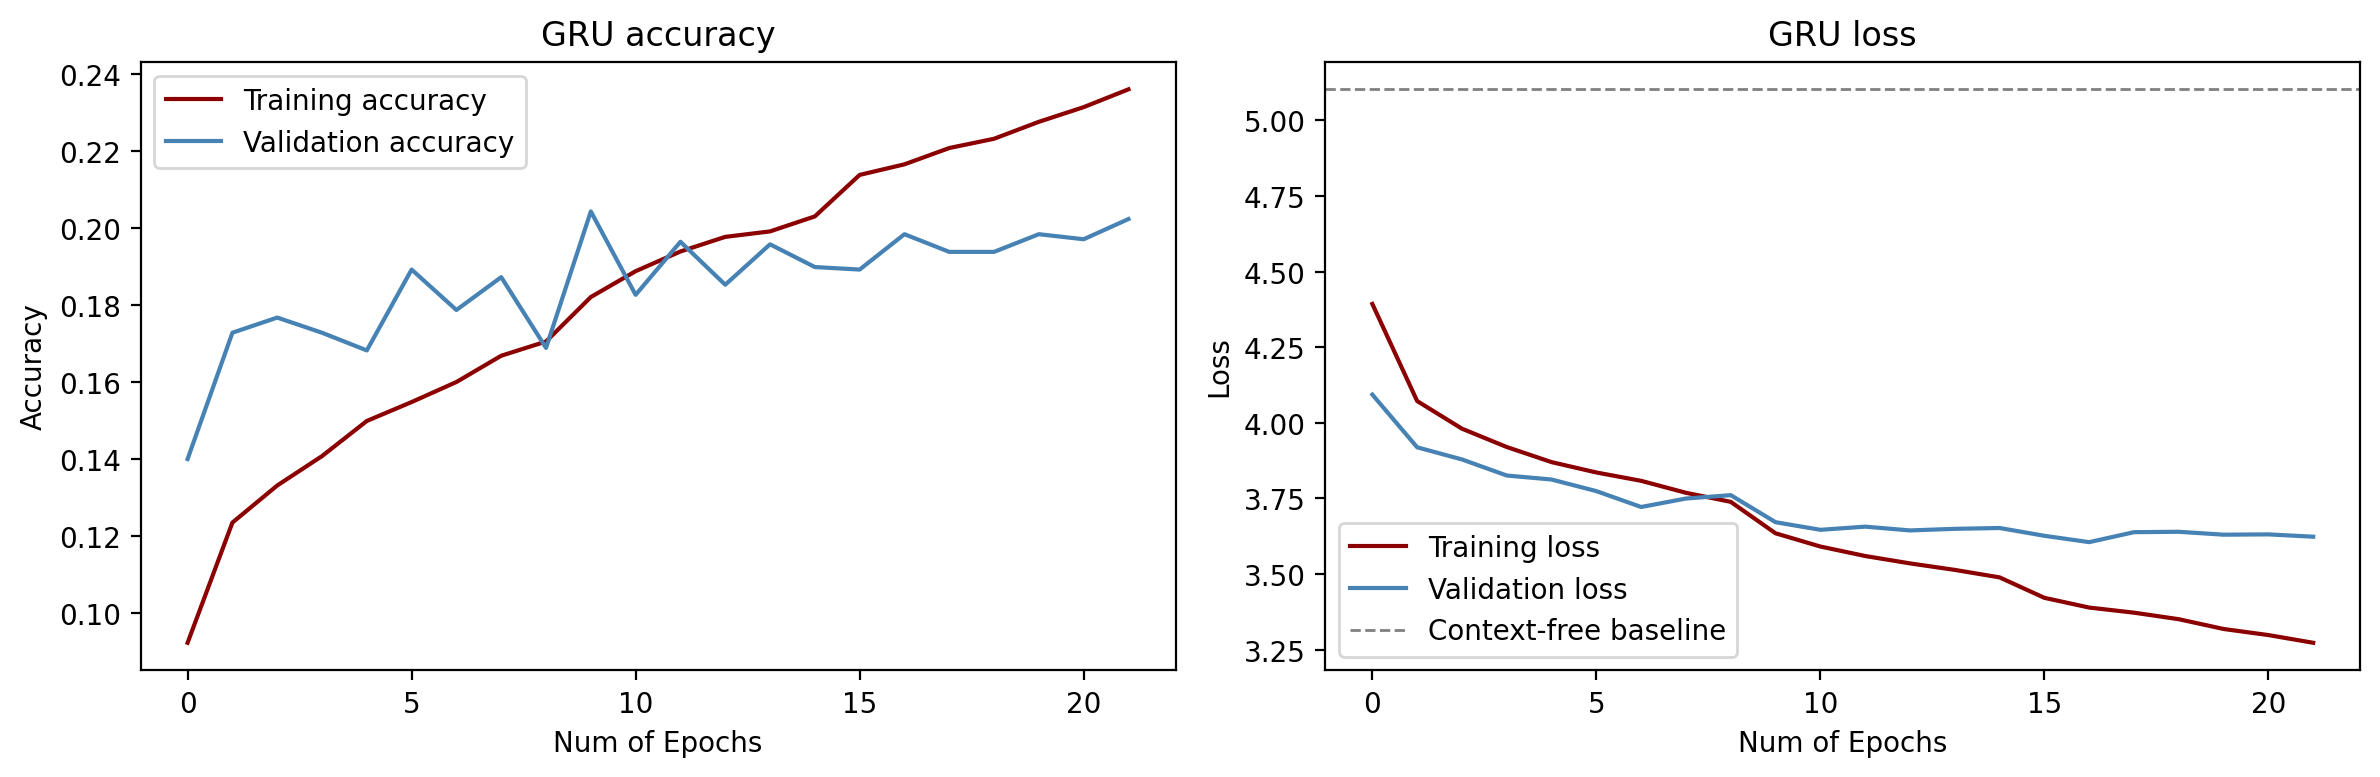

Saved results/audio/gru_improved_generated.mid and results/audio/gru_improved_generated.wav


[Audio player removed to keep this notebook small enough for GitHub. The generated .wav and .mid files are in the repo's results/ folder.]


,0
best_epoch,17.000000
epochs_run,22.000000
train_accuracy,0.216592
val_accuracy,0.198423
val_loss,3.605124
perplexity (exp val loss),36.786236
context-free baseline val loss,5.102639
"novelty (mean distance, as in original code)",3.644232
"novelty (nearest neighbour, as in RESULTS.md)",1.560099
diversity,3.638549


In [10]:
results = {}
if "gru" in MODELS_TO_RUN:
    results["GRU (improved)"] = run_model("gru", layers.GRU)
    display(pd.Series(results["GRU (improved)"]))

### LSTM

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │        91,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 512)       │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 512)            │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 714)            │       183,498 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 714)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,818,186 (14.57 MB)

 Trainable params: 3,818,186 (14.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 90s 59ms/step - accuracy: 0.0156 - loss: 5.0469 - val_accuracy: 0.0151 - val_loss: 4.9727 - learning_rate: 0.0010
Epoch 2/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 91s 62ms/step - accuracy: 0.0329 - loss: 4.7711 - val_accuracy: 0.0329 - val_loss: 4.6752 - learning_rate: 0.0010
Epoch 3/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 92s 63ms/step - accuracy: 0.0553 - loss: 4.5375 - val_accuracy: 0.0637 - val_loss: 4.5000 - learning_rate: 0.0010
Epoch 4/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 92s 63ms/step - accuracy: 0.0792 - loss: 4.3666 - val_accuracy: 0.0591 - val_loss: 4.4518 - learning_rate: 0.0010
Epoch 5/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 92s 63ms/step - accuracy: 0.0762 - loss: 4.3669 - val_accuracy: 0.0775 - val_loss: 4.3177 - learning_rate: 0.0010
Epoch 6/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 92s 63ms/step - accuracy: 0.0930 - loss: 4.2158 - val_accuracy: 0.0999 - val_loss: 4.2149 - learning_rate: 0.0010
Epoch 7/40
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 92s 63ms/step - accura

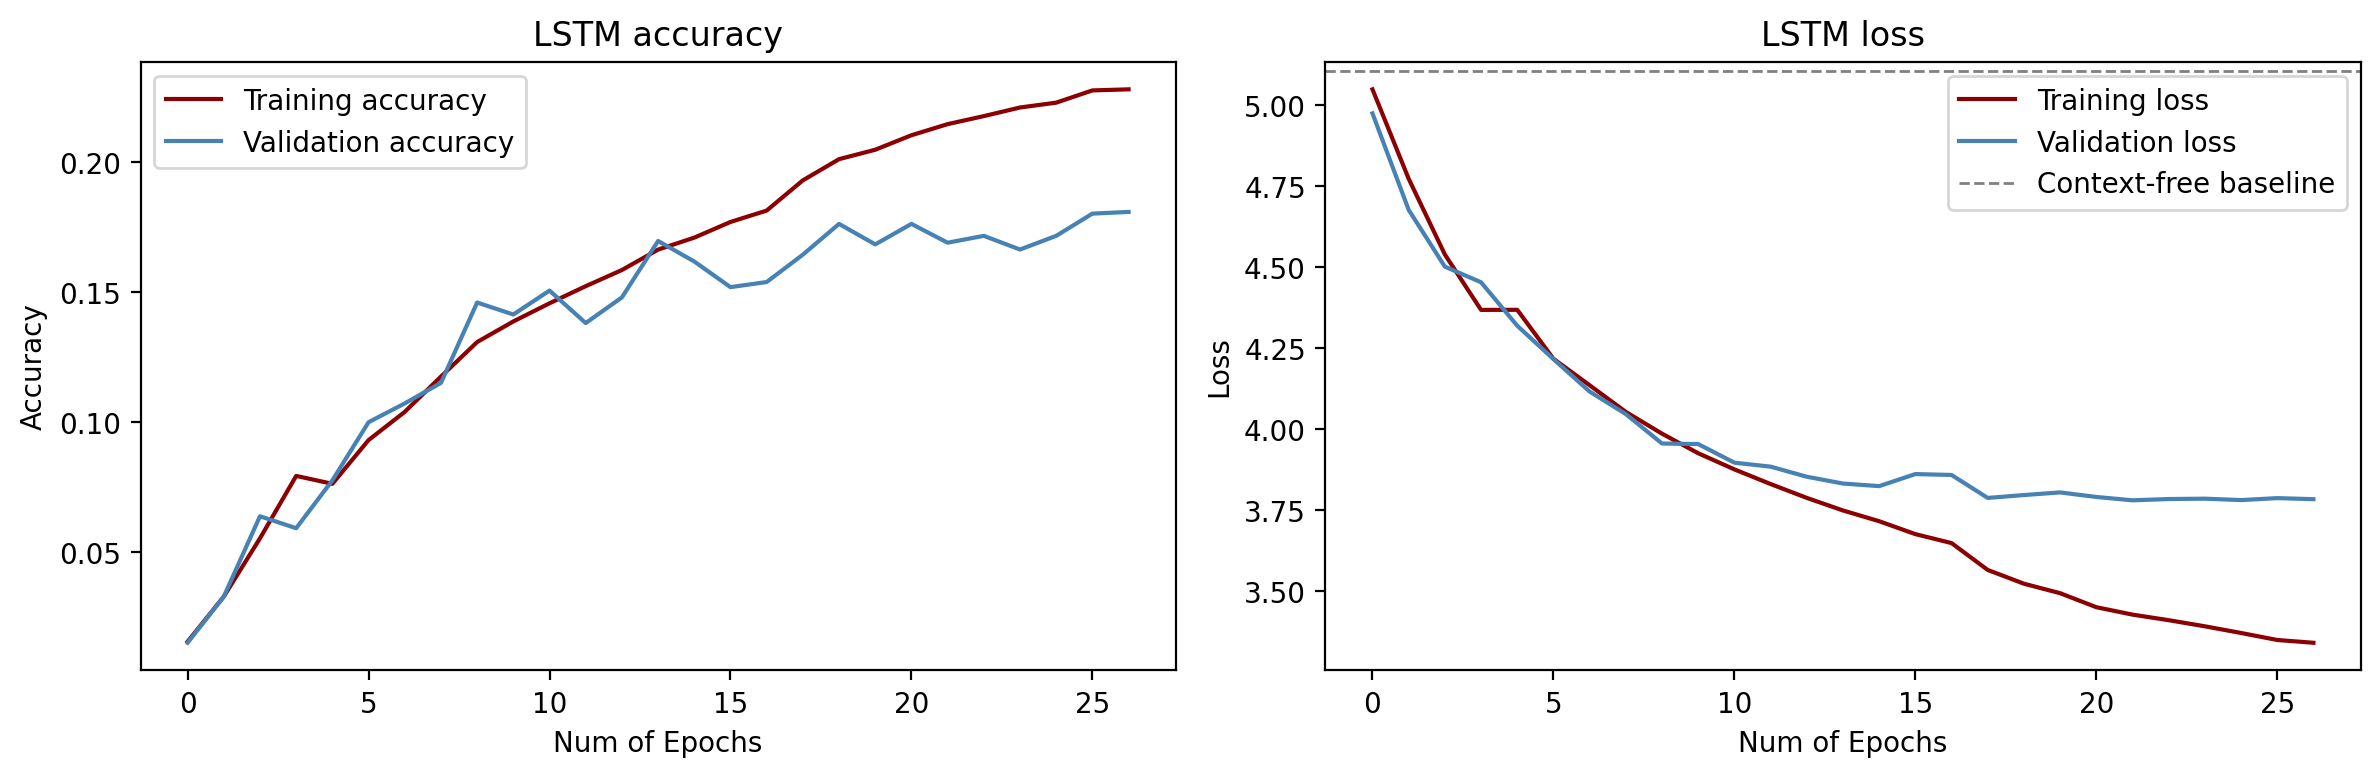

Saved results/audio/lstm_improved_generated.mid and results/audio/lstm_improved_generated.wav


[Audio player removed to keep this notebook small enough for GitHub. The generated .wav and .mid files are in the repo's results/ folder.]


,0
best_epoch,22.000000
epochs_run,27.000000
train_accuracy,0.214415
val_accuracy,0.168857
val_loss,3.779274
perplexity (exp val loss),43.784263
context-free baseline val loss,5.102639
"novelty (mean distance, as in original code)",2.982871
"novelty (nearest neighbour, as in RESULTS.md)",1.061321
diversity,1.656909


In [11]:
if "lstm" in MODELS_TO_RUN:
    results["LSTM (improved)"] = run_model("lstm", layers.LSTM)
    display(pd.Series(results["LSTM (improved)"]))

## 5. Compare with earlier runs

- **Original GRU (2024):** from RESULTS.md. Its 0.454 is *training* accuracy. There was no validation set, and checkpoints were kept on training loss.
- **Reproduction:** the straight port of the 2024 setup to current Keras, which never learned.

The vocabulary and validation set changed, so compare the improved runs mainly against the context-free baseline and against each other. Novelty / diversity / FAD are computed on token ids, so they are only a loose guide.

In [12]:
reference = {
    "Original GRU (2024)": {"train_accuracy": 0.454, "val_loss": 2.0046, "perplexity (exp val loss)": 7.423},
    "Reproduction GRU": {"train_accuracy": 0.0113, "val_accuracy": 0.0109, "val_loss": 5.4289,
                         "perplexity (exp val loss)": 227.90},
    "Reproduction LSTM": {"train_accuracy": 0.0207, "val_accuracy": 0.0116, "val_loss": 5.1230,
                          "perplexity (exp val loss)": 167.83},
}
comparison = pd.DataFrame({**reference, **results})
comparison

,Original GRU (2024),Reproduction GRU,Reproduction LSTM,GRU (improved),LSTM (improved)
train_accuracy,0.4540,0.0113,0.0207,0.216592,0.214415
val_loss,2.0046,5.4289,5.1230,3.605124,3.779274
perplexity (exp val loss),7.4230,227.9000,167.8300,36.786236,43.784263
val_accuracy,NaN,0.0109,0.0116,0.198423,0.168857
best_epoch,NaN,NaN,NaN,17.000000,22.000000
epochs_run,NaN,NaN,NaN,22.000000,27.000000
context-free baseline val loss,NaN,NaN,NaN,5.102639,5.102639
"novelty (mean distance, as in original code)",NaN,NaN,NaN,3.644232,2.982871
"novelty (nearest neighbour, as in RESULTS.md)",NaN,NaN,NaN,1.560099,1.061321
diversity,NaN,NaN,NaN,3.638549,1.656909


**Reading the curves.**

- *Learning:* validation loss falls clearly below the grey baseline line.
- *Overfitting:* training loss keeps falling while validation loss turns upward. Early stopping and the best-checkpoint restore guard against it.
- Training accuracy is measured on transposed windows, so it can sit close to or even below validation accuracy.

In [13]:
# On Colab, download everything this notebook produced (figures, audio, metrics) as one zip.
# Unzip it into the repo's results/ folder to keep the outputs.
if IN_COLAB:
    from google.colab import files
    archive = shutil.make_archive("/content/gru_lstm_results", "zip", REPO_ROOT / "results")
    files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>